In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings 
warnings.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [12]:
df = pd.read_csv(r"C:\Users\Mr.Zabit\Documents\ml_projects\Future_ML_Projects\Future_ML_01_Sales_Forecasting\data\raw\Superstore.csv", encoding='latin-1')
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.0,6.8714


In [13]:
# Convert datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [14]:
# Create a month column for grouping
df["Order_Month"] = df["Order Date"].dt.to_period("M")

# Aggregate total monthly sales
monthly_sales = (
    df.groupby("Order_Month")["Sales"]
    .sum()
    .reset_index()
)

# Convert Period -> Timestamp
monthly_sales["Order_Month"] = monthly_sales["Order_Month"].dt.to_timestamp()

monthly_sales.head()

,Order_Month,Sales
0,2014-01-01,14236.895
1,2014-02-01,4519.892
2,2014-03-01,55691.009
3,2014-04-01,28295.345
4,2014-05-01,23648.287


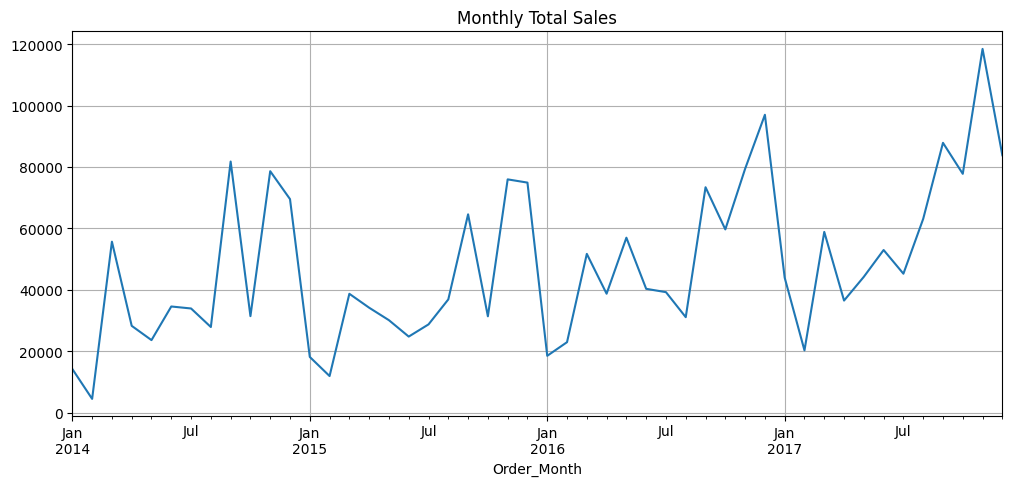

In [15]:
# Set index for time series modeling
ts = monthly_sales.set_index("Order_Month")["Sales"]

# Sort just to be safe
ts = ts.sort_index()

ts.plot(figsize=(12,5), title="Monthly Total Sales", grid=True)
plt.show()

In [16]:
# Define forecasting horizon (you can also use 6)
test_horizon = 12  

train = ts.iloc[:-test_horizon]
test  = ts.iloc[-test_horizon:]

train.tail(), test.head()

(Order_Month
 2016-08-01    31115.3743
 2016-09-01    73410.0249
 2016-10-01    59687.7450
 2016-11-01    79411.9658
 2016-12-01    96999.0430
 Name: Sales, dtype: float64,
 Order_Month
 2017-01-01    43971.3740
 2017-02-01    20301.1334
 2017-03-01    58872.3528
 2017-04-01    36521.5361
 2017-05-01    44261.1102
 Name: Sales, dtype: float64)

In [23]:
# Fit Holt-Winters model
model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal="add",
    seasonal_periods=12
)
fitted_model = model.fit()

In [24]:
forecast = fitted_model.forecast(len(test))
forecast.head()

2017-01-01    33011.503596
2017-02-01    31279.363651
2017-03-01    65133.841473
2017-04-01    53341.561648
2017-05-01    58754.256314
Freq: MS, dtype: float64

In [27]:
# Calculate errors
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
r2score = r2_score(test, forecast)

print("----- Evaluation Metrics -----")
print(f"MAE :     {mae:.2f}")
print(f"RMSE:     {rmse:.2f}")
print(f"MAPE:     {mape:.2f}%")
print(f"R2 Score: {r2score:.4f}")

----- Evaluation Metrics -----
MAE :     11452.92
RMSE:     12540.90
MAPE:     22.59%
R2 Score: 0.7632
